# Limpieza de las *Stable Coins*

## Importaciones

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from IPython.display import display
# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")



## Carga del Dataset

In [27]:
df_stable = pd.read_csv('../data/datos_preprocesados.csv')
df_data_raw = df_stable.copy()
df_stable

,price,market_cap,datetime,peg_deviation,supply_change_1d,supply_change_7d,price_volatility_3d,stablecoin,stablecoin_id,totalLiquidityLocked
0,1.002412,110105.00,2017-12-06,0.002412,0.000000,0.000000,0.001469,USDT,1,0.0
1,1.001515,110105.00,2017-12-07,0.001515,0.000000,0.000000,0.000907,USDT,1,0.0
2,0.999473,110105.00,2017-12-08,0.000527,0.000000,0.000000,0.001506,USDT,1,0.0
3,0.999584,110105.00,2017-12-09,0.000416,0.000000,0.000000,0.001148,USDT,1,0.0
4,1.000546,110105.00,2017-12-10,0.000546,0.000000,0.000000,0.000590,USDT,1,0.0
...,...,...,...,...,...,...,...,...,...,...
21570,1.000686,2934209.00,2026-06-30,0.000686,-0.647774,-0.871983,0.001818,USDE,10,0.0
21571,0.999550,2699100.00,2026-07-01,0.000450,-0.080127,-0.822786,0.001030,USDE,10,0.0
21572,1.000586,3505130.00,2026-07-02,0.000586,0.298629,-0.732802,0.000629,USDE,10,0.0
21573,1.000268,4072406.00,2026-07-03,0.000268,0.161842,-0.571149,0.000531,USDE,10,0.0


## Radiogradia Inicial

In [28]:
# Configuración para ver todas las columnas en el notebook
pd.set_option('display.max_columns', None)

In [29]:
# Se realiza un análisis técnico , "data quality check" para analizar el dataset de forma automática y entender su calidad

# Función 1 :radiografía técnica
def radiografia_tecnica(df):
    print("="*60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("="*60)

    # 1. Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)" if df.size > 0 else "  • Datos faltantes: 0")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Ejemplo de datos
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                        {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show()


# Función 2: El plan de acción (Resumen adaptado)
def plan_accion_datos(df):
    print("\n" + "="*60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("="*60)

    # Duplicados
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    # Nulos
    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    # Montos (amount)
    if 'amount' in df.columns:
        anomalos = (df['amount'] < 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Revisar {anomalos} registros con 'amount' negativo.")

    # Fechas (Específicas de tu tabla: rental_date, return_date)
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    cols_a_convertir = [col for col in cols_fecha if not pd.api.types.is_datetime64_any_dtype(df[col])]

    if cols_a_convertir:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_a_convertir}")

    print("-" * 60)
    print("  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.")
    print("="*60)

# Función 3: Comparativo Snapshot (Sin cambios, es universal)
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    def get_metrics(df):
        return [
            f"{len(df):,}",
            df.shape[1],
            f"{df.isnull().sum().sum():,}",
            f"{(df.isnull().sum().sum() / df.size * 100 if df.size > 0 else 0):.2f}%",
            df.duplicated().sum(),
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]

    metrics = {
        'Métrica': ['Filas Totales', 'Columnas', 'Celdas con Nulos', '% Global de Nulos', 'Filas Duplicadas', 'Memoria (MB)'],
        'Snapshot Inicial': get_metrics(df_inicial),
        'Snapshot Final': get_metrics(df_final)
    }

    comparativa_df = pd.DataFrame(metrics)

    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 21,575
  • Columnas: 10
  • Celdas totales: 215,750
  • Datos faltantes: 0 (0.00%)
  • Filas duplicadas: 0
  • Uso de memoria: 3.63 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
price,float64,21575,0,0.00%,21557,99.92%,1.002412
market_cap,float64,21575,0,0.00%,20601,95.49%,110105.000000
datetime,str,21575,0,0.00%,3133,14.52%,2017-12-06
peg_deviation,float64,21575,0,0.00%,21557,99.92%,0.002412
supply_change_1d,float64,21575,0,0.00%,20809,96.45%,0.000000
supply_change_7d,float64,21575,0,0.00%,20970,97.20%,0.000000
price_volatility_3d,float64,21575,0,0.00%,21575,100.00%,0.001469
stablecoin,str,21575,0,0.00%,10,0.05%,USDT
stablecoin_id,int64,21575,0,0.00%,10,0.05%,1
totalLiquidityLocked,float64,21575,0,0.00%,1,0.00%,0.000000


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
price,21575.0,9.999600e-01,1.892688e-03,9.420000e-01,9.991939e-01,9.999979e-01,1.000808e+00,1.005042e+00
market_cap,21575.0,1.546335e+10,3.468685e+10,1.101050e+05,1.322493e+08,6.929045e+08,6.569135e+09,1.902405e+11
peg_deviation,21575.0,1.004683e-03,1.604504e-03,2.155425e-07,3.848583e-04,8.073728e-04,1.388404e-03,5.800000e-02
supply_change_1d,21575.0,1.516249e-02,1.859014e+00,-8.615129e-01,-2.293128e-03,8.738229e-05,3.631028e-03,2.728006e+02
supply_change_7d,21575.0,1.053735e-01,4.916832e+00,-8.719827e-01,-1.004525e-02,9.861619e-04,1.954086e-02,2.728006e+02
price_volatility_3d,21575.0,1.139032e-03,1.514133e-03,8.651009e-06,6.389432e-04,1.003046e-03,1.432185e-03,3.477824e-02
stablecoin_id,21575.0,5.267856e+00,2.931759e+00,1.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.000000e+01
totalLiquidityLocked,21575.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


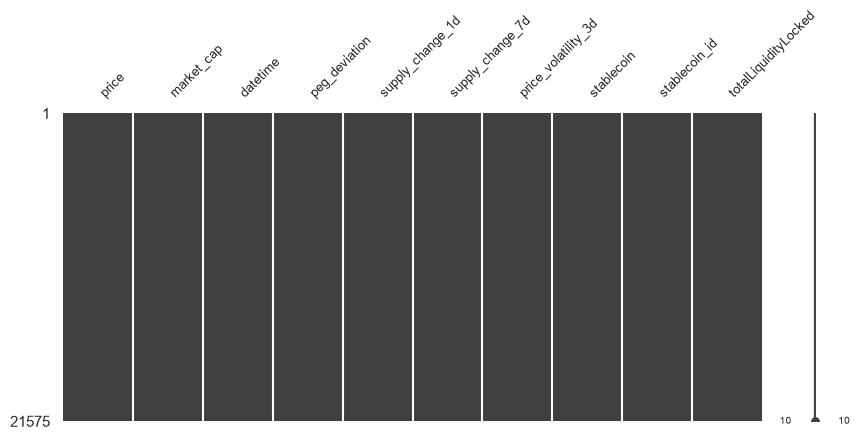


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] FORMATO: Convertir a datetime: ['datetime']
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.


In [30]:
# Para ver el estado actual:
radiografia_tecnica(df_stable)

# Para ver qué deberías limpiar:
plan_accion_datos(df_stable)

In [31]:
df_stable.info()

<class 'pandas.DataFrame'>
RangeIndex: 21575 entries, 0 to 21574
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 21575 non-null  float64
 1   market_cap            21575 non-null  float64
 2   datetime              21575 non-null  str    
 3   peg_deviation         21575 non-null  float64
 4   supply_change_1d      21575 non-null  float64
 5   supply_change_7d      21575 non-null  float64
 6   price_volatility_3d   21575 non-null  float64
 7   stablecoin            21575 non-null  str    
 8   stablecoin_id         21575 non-null  int64  
 9   totalLiquidityLocked  21575 non-null  float64
dtypes: float64(7), int64(1), str(2)
memory usage: 1.6 MB
